# Train an MLP baseline on IBL Brain Wide Map data

In this notebook we train a **Multi-Layer Perceptron (MLP)** from scratch to decode
wheel velocity from binned spike counts.

The MLP is a classic baseline: it bins the population activity into a flat feature vector
and learns a direct linear mapping (with non-linearities) to the output signal. Unlike
POYO, it ignores the identity of individual neurons (no unit embeddings) and does not
leverage temporal structure within the context window.

**Experiment**: we train three separate models, each restricted to a different subset of
units selected by brain region:
1. **motor** — primary and secondary motor cortex units
2. **caudoputamen** — striatal units
3. **both** — motor + caudoputamen combined

Because `num_units` is baked into the MLP's first linear layer, each model is constructed
independently with the filtered unit count.  A `UnitFilter` transform is chained before
`model.tokenize` to drop non-selected units and remap spike indices.

**Key design choices:**
- `bin_size`: temporal resolution of the *input* spike bins (10 ms → 100 bins/s)
- `readout_sampling_rate`: native sampling rate of the target signal (1000 Hz)
- These two are decoupled — the model maps `(T_in, N) → (T_out, D)`

**References:**
- [IBL Brain Wide Map](https://dandiarchive.org/dandiset/000409/draft)
- [POYO](https://poyo-brain.github.io/)

In [1]:
from pathlib import Path
import numpy as np
import torch
import torch_brain
from torch_brain.registry import MODALITY_REGISTRY, DataType
from torch_brain.transforms import UnitFilter, Compose

from mlp import MLPNeuralDecoder
from aux_functions import (
    get_loaders,
    get_unit_ids,
    move_to_device,
    pearson_r,
    compute_r2,
    training_step,
    plot_training_curves,
    plot_test_intervals,
)

## 1. Dataset

In [2]:
# List of recording IDs to use (h5 file stems, without the .h5 extension)
recording_ids = [
    "sub-CSHL059_ses-d2f5a130-b981-4546-8858-c94ae1da75ff_desc-processed_behavior+ecephys",
    #"sub-NYU-21_ses-8c33abef-3d3e-4d42-9f27-445e9def08f9_desc-processed_behavior+ecephys",
    #"sub-UCLA035_ses-6f36868f-5cc1-450c-82fa-6b9829ce0cfe_desc-processed_behavior+ecephys",
    #"sub-DY-011_ses-7bee9f09-a238-42cf-b499-f51f765c6ded_desc-processed_behavior+ecephys",
    #"sub-DY-014_ses-bd456d8f-d36e-434a-8051-ff3997253802_desc-processed_behavior+ecephys",
    #"sub-NR-0027_ses-ae8787b1-4229-4d56-b0c2-566b61a25b77_desc-processed_behavior+ecephys",
    #"sub-SWC-038_ses-03063955-2523-47bd-ae57-f7489dd40f15_desc-processed_behavior+ecephys",
    #"sub-ZFM-01936_ses-4aa1d525-5c7d-4c50-a147-ec53a9014812_desc-processed_behavior+ecephys",
    #"sub-CSH-ZAD-026_ses-81a78eac-9d36-4f90-a73a-7eb3ad7f770b_desc-processed_behavior+ecephys",
    #"sub-CSH-ZAD-026_ses-626126d5-eecf-4e9b-900e-ec29a17ece07_desc-processed_behavior+ecephys",
    #"sub-CSH-ZAD-026_ses-b69b86be-af7d-4ecf-8cbf-0cd356afa1bd_desc-processed_behavior+ecephys",
    #"sub-CSH-ZAD-026_ses-e56541a5-a6d5-4750-b1fe-f6b5257bfe7c_desc-processed_behavior+ecephys",
]

dir_path = Path(".").resolve()

dataset, train_loader, val_loader, test_loader = get_loaders(
    dir_path=dir_path,
    recording_ids=recording_ids,
    readout_id="wheel_velocity",
    window_length=1.0,
    batch_size=16,
)

print(f"Recordings  : {len(dataset.recording_ids)}")
print(f"Total units : {len(dataset.get_unit_ids())}")

Recordings  : 1
Total units : 1669


## 2. Register the output modality

In [3]:
# Only register if not already registered (safe for re-running the cell)
if "wheel_velocity" not in MODALITY_REGISTRY:
    torch_brain.register_modality(
        name="wheel_velocity",
        dim=1,
        type=DataType.CONTINUOUS,
        timestamp_key="wheel_velocity.timestamps",
        value_key="wheel_velocity.values",
        loss_fn=torch_brain.nn.loss.MSELoss(),
    )

readout_spec = MODALITY_REGISTRY["wheel_velocity"]
print(readout_spec)

ModalitySpec(id=20, dim=1, type=<DataType.CONTINUOUS: 0>, timestamp_key='wheel_velocity.timestamps', value_key='wheel_velocity.values', loss_fn=MSELoss())


## 3. Hyperparameters and device

In [4]:
device = (
    torch.device("mps") if torch.backends.mps.is_available()
    else torch.device("cuda:0") if torch.cuda.is_available()
    else torch.device("cpu")
)
print(f"Using device: {device}")

BIN_SIZE        = 10e-3    # 10 ms  → 100 input bins / second
SEQUENCE_LENGTH = 1.0      # 1-second context window
READOUT_RATE    = 1000.0   # Hz  → 1000 output steps / second
HIDDEN_DIM      = 256
NUM_EPOCHS      = 20
LR              = 1e-3
QUALITY_SCORE   = 0.6      # IBL quality score threshold

Using device: mps


## 4. Train one MLP per brain-region subset

We train **three separate MLP models**, each receiving spikes from a different subset of
recorded units selected by brain region:

| Experiment | Region filter | Key question |
|---|---|---|
| **4a. motor** | Primary & secondary motor cortex | Motor cortex alone is sufficient to decode wheel velocity? |
| **4b. caudoputamen** | Striatum (caudoputamen) | Striatal activity also encodes wheel kinematics? |
| **4c. both** | Motor + caudoputamen combined | Does adding more regions improve decoding? |

### Why each model must be built separately

Unlike POYO — which uses an infinite-vocabulary unit embedding and can handle any set of units at
inference time — the MLP bakes `num_units` directly into its first linear layer:

```python
nn.Linear(num_input_bins * num_units, hidden_dim)
```

This means the **unit count must be fixed before the model is constructed**.  The workflow for
each experiment is therefore:

1. `get_unit_ids(dataset, filter_str=..., quality_score=...)` → list of valid unit IDs
2. `UnitFilter(mask_fn=..., field="spikes", reset_index=True)` → drops unwanted units and
   remaps `spikes.unit_index` to `0 … N_filtered-1`
3. `MLPNeuralDecoder(num_units=N_filtered, ...)` → model parametrized for that unit count
4. `dataset.transform = Compose([unit_filter, model.tokenize])` → apply filter then tokenize
5. Standard training loop with `training_step` / `compute_r2`

Results are stored in shared dicts (`trained_models`, `unit_filters`, …) for the comparison in
Section 5.

In [5]:
# Shared containers — populated by each sub-section below
trained_models   = {}   # label -> trained MLPNeuralDecoder
unit_filters     = {}   # label -> UnitFilter transform
r2_logs_by_exp   = {}   # label -> val R² log (for training curves)
loss_logs_by_exp = {}   # label -> training loss log

### 4a. Motor cortex

Units in **primary and secondary motor cortex** (location name contains `"motor"`). These areas
are directly involved in planning and executing voluntary movements, so we expect a strong
correlation with wheel velocity.

In [6]:
LABEL = "motor"
FILTER_STRS = ["motor"]

# 1. Filter unit IDs by region and quality
unit_ids_motor = get_unit_ids(dataset, filter_str=FILTER_STRS, quality_score=QUALITY_SCORE)
print(f"Motor units (quality > {QUALITY_SCORE}): {len(unit_ids_motor)}")

# 2. Build UnitFilter — keeps only selected units, remaps spike indices
valid_set_motor = set(unit_ids_motor)
unit_filter_motor = UnitFilter(
    mask_fn=lambda units, vs=valid_set_motor: np.array([uid in vs for uid in units.id]),
    field="spikes",
    reset_index=True,
)
unit_filters[LABEL] = unit_filter_motor

# 3. Build MLP with the filtered unit count
model_motor = MLPNeuralDecoder(
    num_units=len(unit_ids_motor),
    bin_size=BIN_SIZE,
    sequence_length=SEQUENCE_LENGTH,
    readout_spec=readout_spec,
    readout_sampling_rate=READOUT_RATE,
    hidden_dim=HIDDEN_DIM,
).to(device).float()
n_params = sum(p.numel() for p in model_motor.parameters() if p.requires_grad)
print(f"Input bins: {model_motor.num_input_bins}  Output steps: {model_motor.num_output_steps}  Params: {n_params:,}")

# 4. Chain transforms: filter → tokenize
dataset.transform = Compose([unit_filter_motor, model_motor.tokenize])

# 5. Train
opt_motor = torch.optim.AdamW(model_motor.parameters(), lr=LR)
r2_log_motor, loss_log_motor = [], []

for epoch in range(NUM_EPOCHS):
    val_r2, _, _ = compute_r2(val_loader, model_motor)
    r2_log_motor.append(val_r2)

    model_motor.train()
    epoch_loss = 0.0
    for batch in train_loader:
        batch = move_to_device(batch, device)
        loss = training_step(batch, model_motor, opt_motor)
        loss_log_motor.append(loss.item())
        epoch_loss += loss.item()
    print(f"  Epoch {epoch+1:3d}/{NUM_EPOCHS}  loss={epoch_loss/len(train_loader):.4f}  val_R²={val_r2:.3f}")

final_r2, _, _ = compute_r2(val_loader, model_motor)
r2_log_motor.append(final_r2)
print(f"✅ Motor — final val R² = {final_r2:.3f}")

trained_models[LABEL]   = model_motor
r2_logs_by_exp[LABEL]   = r2_log_motor
loss_logs_by_exp[LABEL] = loss_log_motor

Motor units (quality > 0.6): 265
Input bins: 100  Output steps: 1000  Params: 7,107,048
  Epoch   1/20  loss=1.8489  val_R²=-0.032
  Epoch   2/20  loss=1.4445  val_R²=0.299
  Epoch   3/20  loss=1.3120  val_R²=0.331
  Epoch   4/20  loss=1.1004  val_R²=0.340
  Epoch   5/20  loss=0.9974  val_R²=0.453
  Epoch   6/20  loss=0.9283  val_R²=0.458
  Epoch   7/20  loss=0.9492  val_R²=0.459
  Epoch   8/20  loss=0.8143  val_R²=0.492
  Epoch   9/20  loss=0.8226  val_R²=0.493
  Epoch  10/20  loss=0.7478  val_R²=0.461
  Epoch  11/20  loss=0.7748  val_R²=0.460
  Epoch  12/20  loss=0.6991  val_R²=0.492
  Epoch  13/20  loss=0.6988  val_R²=0.525
  Epoch  14/20  loss=0.6738  val_R²=0.542
  Epoch  15/20  loss=0.6523  val_R²=0.557
  Epoch  16/20  loss=0.6177  val_R²=0.560
  Epoch  17/20  loss=0.6133  val_R²=0.560
  Epoch  18/20  loss=0.5812  val_R²=0.524
  Epoch  19/20  loss=0.5742  val_R²=0.555
  Epoch  20/20  loss=0.5346  val_R²=0.554
✅ Motor — final val R² = 0.577


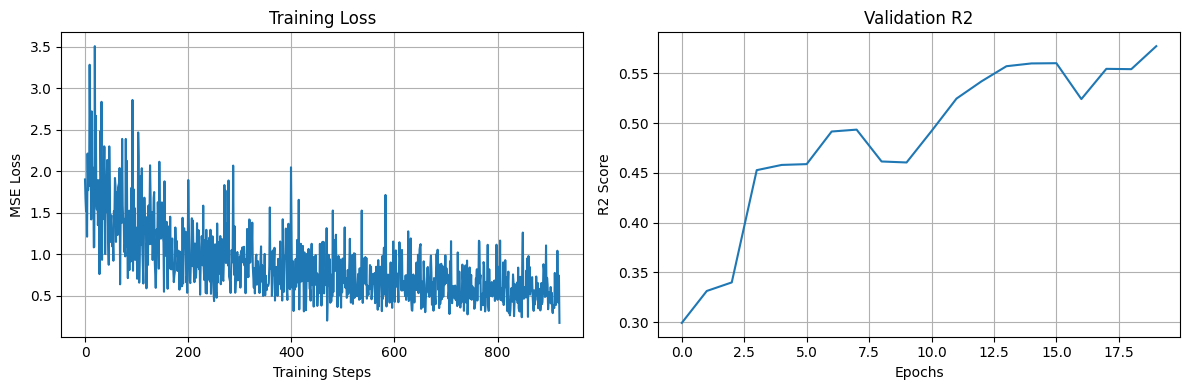

In [7]:
plot_training_curves(r2_log_motor, loss_log_motor)

### 4b. Caudoputamen (striatum)

Units in the **caudoputamen** — the dorsal striatum. This region is part of the basal ganglia
and is involved in action selection and motor control. It receives strong projections from motor
cortex, so its activity may also correlate with wheel kinematics.

In [8]:
LABEL = "caudoputamen"
FILTER_STRS = ["caudoputamen"]

unit_ids_cp = get_unit_ids(dataset, filter_str=FILTER_STRS, quality_score=QUALITY_SCORE)
print(f"Caudoputamen units (quality > {QUALITY_SCORE}): {len(unit_ids_cp)}")

valid_set_cp = set(unit_ids_cp)
unit_filter_cp = UnitFilter(
    mask_fn=lambda units, vs=valid_set_cp: np.array([uid in vs for uid in units.id]),
    field="spikes",
    reset_index=True,
)
unit_filters[LABEL] = unit_filter_cp

model_cp = MLPNeuralDecoder(
    num_units=len(unit_ids_cp),
    bin_size=BIN_SIZE,
    sequence_length=SEQUENCE_LENGTH,
    readout_spec=readout_spec,
    readout_sampling_rate=READOUT_RATE,
    hidden_dim=HIDDEN_DIM,
).to(device).float()
n_params = sum(p.numel() for p in model_cp.parameters() if p.requires_grad)
print(f"Input bins: {model_cp.num_input_bins}  Output steps: {model_cp.num_output_steps}  Params: {n_params:,}")

dataset.transform = Compose([unit_filter_cp, model_cp.tokenize])

opt_cp = torch.optim.AdamW(model_cp.parameters(), lr=LR)
r2_log_cp, loss_log_cp = [], []

for epoch in range(NUM_EPOCHS):
    val_r2, _, _ = compute_r2(val_loader, model_cp)
    r2_log_cp.append(val_r2)

    model_cp.train()
    epoch_loss = 0.0
    for batch in train_loader:
        batch = move_to_device(batch, device)
        loss = training_step(batch, model_cp, opt_cp)
        loss_log_cp.append(loss.item())
        epoch_loss += loss.item()
    print(f"  Epoch {epoch+1:3d}/{NUM_EPOCHS}  loss={epoch_loss/len(train_loader):.4f}  val_R²={val_r2:.3f}")

final_r2, _, _ = compute_r2(val_loader, model_cp)
r2_log_cp.append(final_r2)
print(f"✅ Caudoputamen — final val R² = {final_r2:.3f}")

trained_models[LABEL]   = model_cp
r2_logs_by_exp[LABEL]   = r2_log_cp
loss_logs_by_exp[LABEL] = loss_log_cp

Caudoputamen units (quality > 0.6): 345
Input bins: 100  Output steps: 1000  Params: 9,155,048
  Epoch   1/20  loss=1.9460  val_R²=-0.031
  Epoch   2/20  loss=1.4917  val_R²=0.329
  Epoch   3/20  loss=1.2437  val_R²=0.378
  Epoch   4/20  loss=1.1129  val_R²=0.365
  Epoch   5/20  loss=1.0266  val_R²=0.470
  Epoch   6/20  loss=0.9662  val_R²=0.444
  Epoch   7/20  loss=0.8935  val_R²=0.464
  Epoch   8/20  loss=0.8683  val_R²=0.513
  Epoch   9/20  loss=0.8549  val_R²=0.484
  Epoch  10/20  loss=0.7723  val_R²=0.504
  Epoch  11/20  loss=0.7490  val_R²=0.485
  Epoch  12/20  loss=0.7093  val_R²=0.497
  Epoch  13/20  loss=0.6787  val_R²=0.503
  Epoch  14/20  loss=0.6711  val_R²=0.539
  Epoch  15/20  loss=0.6690  val_R²=0.516
  Epoch  16/20  loss=0.5979  val_R²=0.529
  Epoch  17/20  loss=0.6019  val_R²=0.543
  Epoch  18/20  loss=0.5794  val_R²=0.547
  Epoch  19/20  loss=0.5979  val_R²=0.549
  Epoch  20/20  loss=0.5633  val_R²=0.533
✅ Caudoputamen — final val R² = 0.556


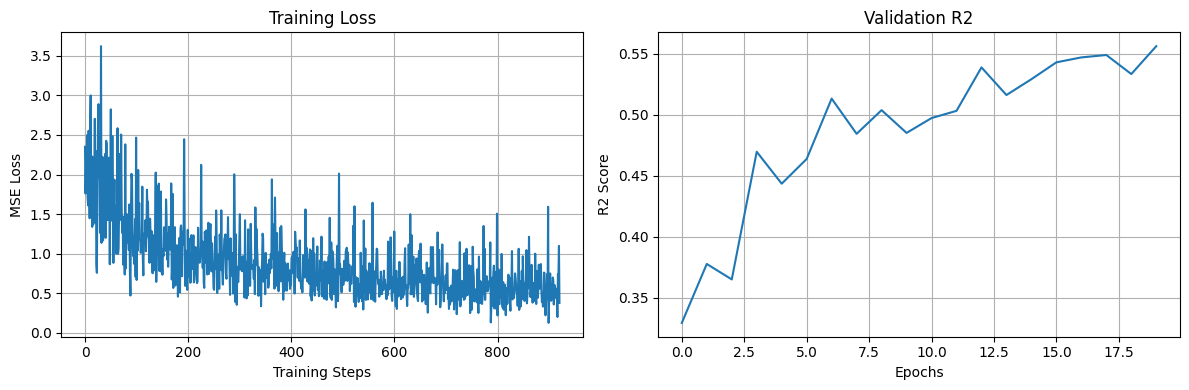

In [9]:
plot_training_curves(r2_log_cp, loss_log_cp)

### 4c. Both regions combined

Combine all **motor cortex + caudoputamen** units into a single input. With more units the
model's input layer is larger (`num_input_bins × (N_motor + N_cp)`), giving it access to
complementary signals from both regions.

In [10]:
LABEL = "both"
FILTER_STRS = ["motor", "caudoputamen"]

unit_ids_both = get_unit_ids(dataset, filter_str=FILTER_STRS, quality_score=QUALITY_SCORE)
print(f"Motor + caudoputamen units (quality > {QUALITY_SCORE}): {len(unit_ids_both)}")

valid_set_both = set(unit_ids_both)
unit_filter_both = UnitFilter(
    mask_fn=lambda units, vs=valid_set_both: np.array([uid in vs for uid in units.id]),
    field="spikes",
    reset_index=True,
)
unit_filters[LABEL] = unit_filter_both

model_both = MLPNeuralDecoder(
    num_units=len(unit_ids_both),
    bin_size=BIN_SIZE,
    sequence_length=SEQUENCE_LENGTH,
    readout_spec=readout_spec,
    readout_sampling_rate=READOUT_RATE,
    hidden_dim=HIDDEN_DIM,
).to(device).float()
n_params = sum(p.numel() for p in model_both.parameters() if p.requires_grad)
print(f"Input bins: {model_both.num_input_bins}  Output steps: {model_both.num_output_steps}  Params: {n_params:,}")

dataset.transform = Compose([unit_filter_both, model_both.tokenize])

opt_both = torch.optim.AdamW(model_both.parameters(), lr=LR)
r2_log_both, loss_log_both = [], []

for epoch in range(NUM_EPOCHS):
    val_r2, _, _ = compute_r2(val_loader, model_both)
    r2_log_both.append(val_r2)

    model_both.train()
    epoch_loss = 0.0
    for batch in train_loader:
        batch = move_to_device(batch, device)
        loss = training_step(batch, model_both, opt_both)
        loss_log_both.append(loss.item())
        epoch_loss += loss.item()
    print(f"  Epoch {epoch+1:3d}/{NUM_EPOCHS}  loss={epoch_loss/len(train_loader):.4f}  val_R²={val_r2:.3f}")

final_r2, _, _ = compute_r2(val_loader, model_both)
r2_log_both.append(final_r2)
print(f"✅ Both — final val R² = {final_r2:.3f}")

trained_models[LABEL]   = model_both
r2_logs_by_exp[LABEL]   = r2_log_both
loss_logs_by_exp[LABEL] = loss_log_both

Motor + caudoputamen units (quality > 0.6): 610
Input bins: 100  Output steps: 1000  Params: 15,939,048
  Epoch   1/20  loss=1.9076  val_R²=-0.030
  Epoch   2/20  loss=1.5124  val_R²=0.165
  Epoch   3/20  loss=1.2168  val_R²=0.330
  Epoch   4/20  loss=1.0879  val_R²=0.465
  Epoch   5/20  loss=0.9787  val_R²=0.406
  Epoch   6/20  loss=0.8746  val_R²=0.490
  Epoch   7/20  loss=0.8075  val_R²=0.462
  Epoch   8/20  loss=0.8248  val_R²=0.479
  Epoch   9/20  loss=0.7974  val_R²=0.502
  Epoch  10/20  loss=0.7040  val_R²=0.526
  Epoch  11/20  loss=0.6864  val_R²=0.521
  Epoch  12/20  loss=0.6996  val_R²=0.542
  Epoch  13/20  loss=0.6696  val_R²=0.550
  Epoch  14/20  loss=0.6120  val_R²=0.558
  Epoch  15/20  loss=0.5812  val_R²=0.527
  Epoch  16/20  loss=0.5699  val_R²=0.545
  Epoch  17/20  loss=0.5375  val_R²=0.552
  Epoch  18/20  loss=0.5098  val_R²=0.573
  Epoch  19/20  loss=0.5146  val_R²=0.571
  Epoch  20/20  loss=0.5017  val_R²=0.553
✅ Both — final val R² = 0.562


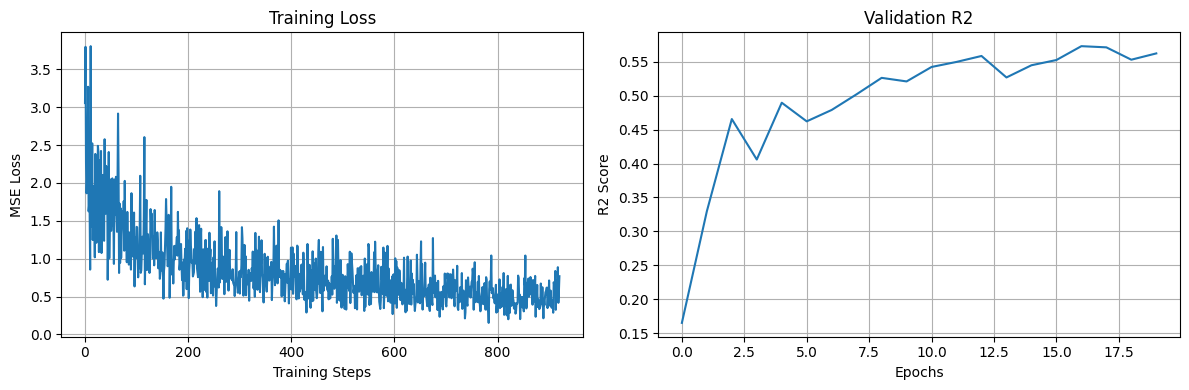

In [11]:
plot_training_curves(r2_log_both, loss_log_both)

## 5. Test set evaluation and comparison

In [12]:
test_results = {}  # label -> {targets, preds, r2_scores}

for label, m in trained_models.items():
    m.eval()
    # Restore the unit filter + tokenize transform for this model
    dataset.transform = Compose([unit_filters[label], m.tokenize])

    targets, preds, r2_scores = [], [], []
    with torch.no_grad():
        for batch in test_loader:
            batch  = move_to_device(batch, device)
            pred   = m(**batch["model_inputs"]).squeeze(-1)   # (B, T_out)
            target = batch["target_values"]                    # (B, T_out)

            for i in range(pred.shape[0]):
                r = pearson_r(pred[i], target[i])
                preds.append(pred[i])
                targets.append(target[i])
                r2_scores.append(r.item())

    median_r2 = float(np.nanmedian(r2_scores))
    mean_r2   = float(np.nanmean(r2_scores))
    print(f"{label:15s}  Test R²  median={median_r2:.3f}   mean={mean_r2:.3f}")
    test_results[label] = dict(targets=targets, preds=preds, r2_scores=r2_scores)

motor            Test R²  median=0.577   mean=0.490
caudoputamen     Test R²  median=0.517   mean=0.435
both             Test R²  median=0.630   mean=0.510


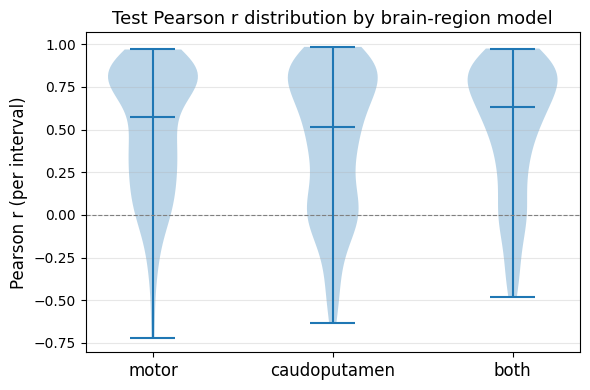

motor            n= 201  median=0.577  mean=0.490  std=0.382
caudoputamen     n= 201  median=0.517  mean=0.435  std=0.418
both             n= 201  median=0.630  mean=0.510  std=0.383


In [13]:
# Summary: R² distribution per brain-region model
import matplotlib.pyplot as plt

labels = list(test_results.keys())
r2_data = [
    np.array(test_results[lb]["r2_scores"])
    for lb in labels
]
# Remove NaN for cleaner plots
r2_clean = [arr[~np.isnan(arr)] for arr in r2_data]

fig, ax = plt.subplots(figsize=(6, 4))
parts = ax.violinplot(r2_clean, showmedians=True, showextrema=True)
ax.set_xticks(range(1, len(labels) + 1))
ax.set_xticklabels(labels, fontsize=12)
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.set_ylabel("Pearson r (per interval)", fontsize=12)
ax.set_title("Test Pearson r distribution by brain-region model", fontsize=13)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

for lb, arr in zip(labels, r2_clean):
    print(f"{lb:15s}  n={len(arr):4d}  "
          f"median={np.median(arr):.3f}  mean={np.mean(arr):.3f}  std={np.std(arr):.3f}")

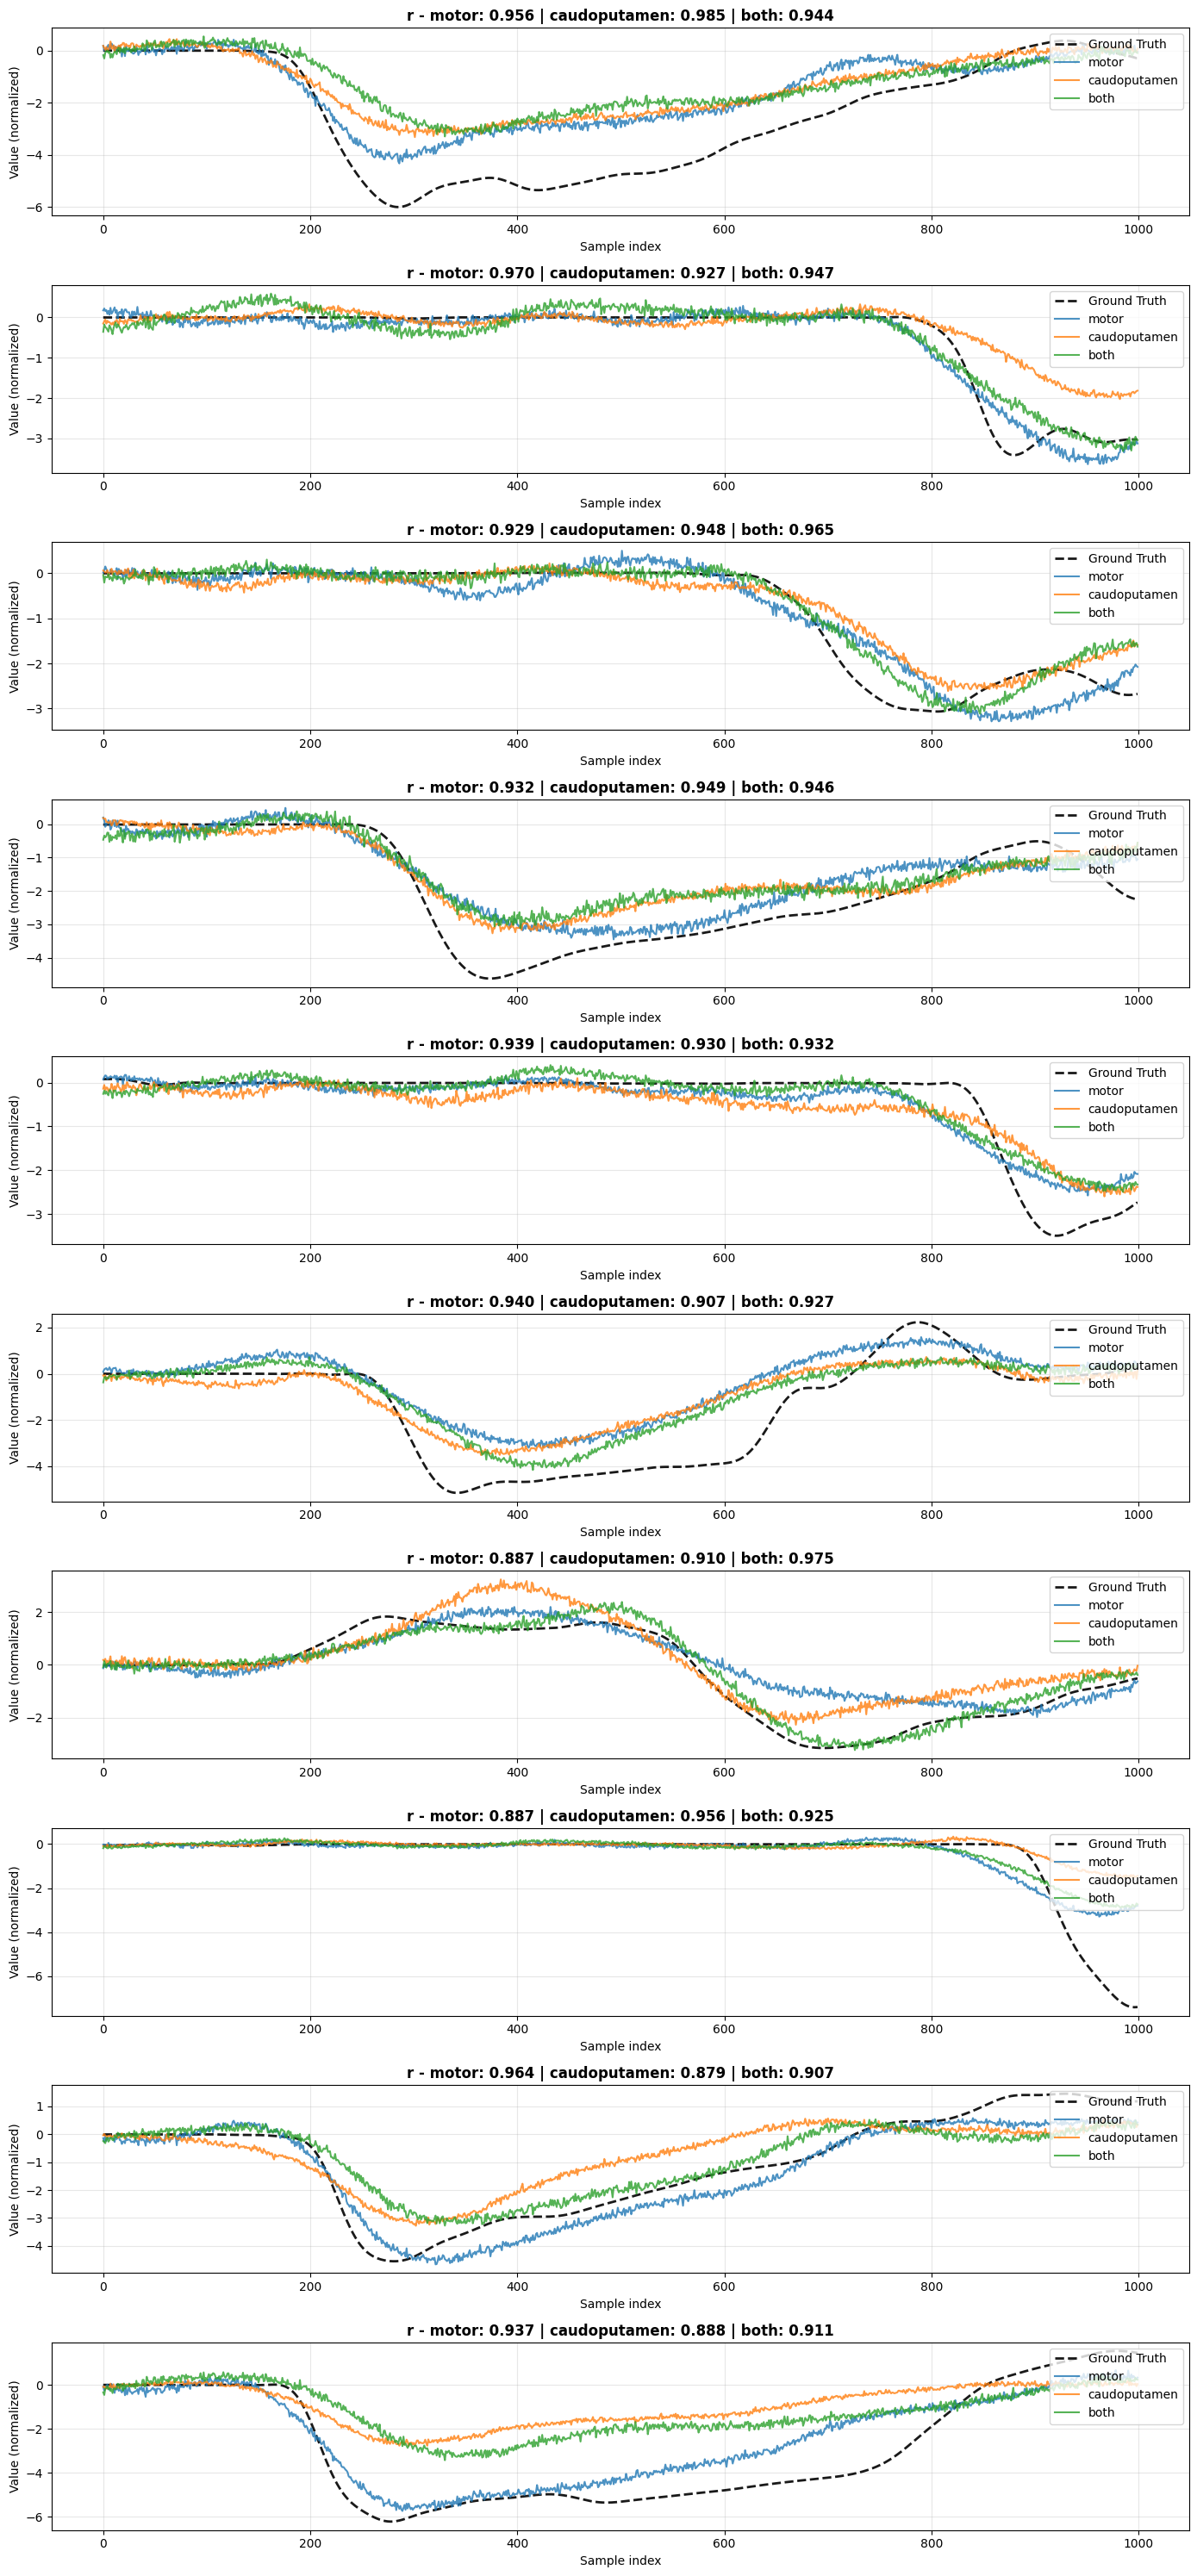

In [14]:
# Compare best intervals across all three models side-by-side
plot_test_intervals(
    test_results=test_results,
    n_intervals=10,
    order="top",
)

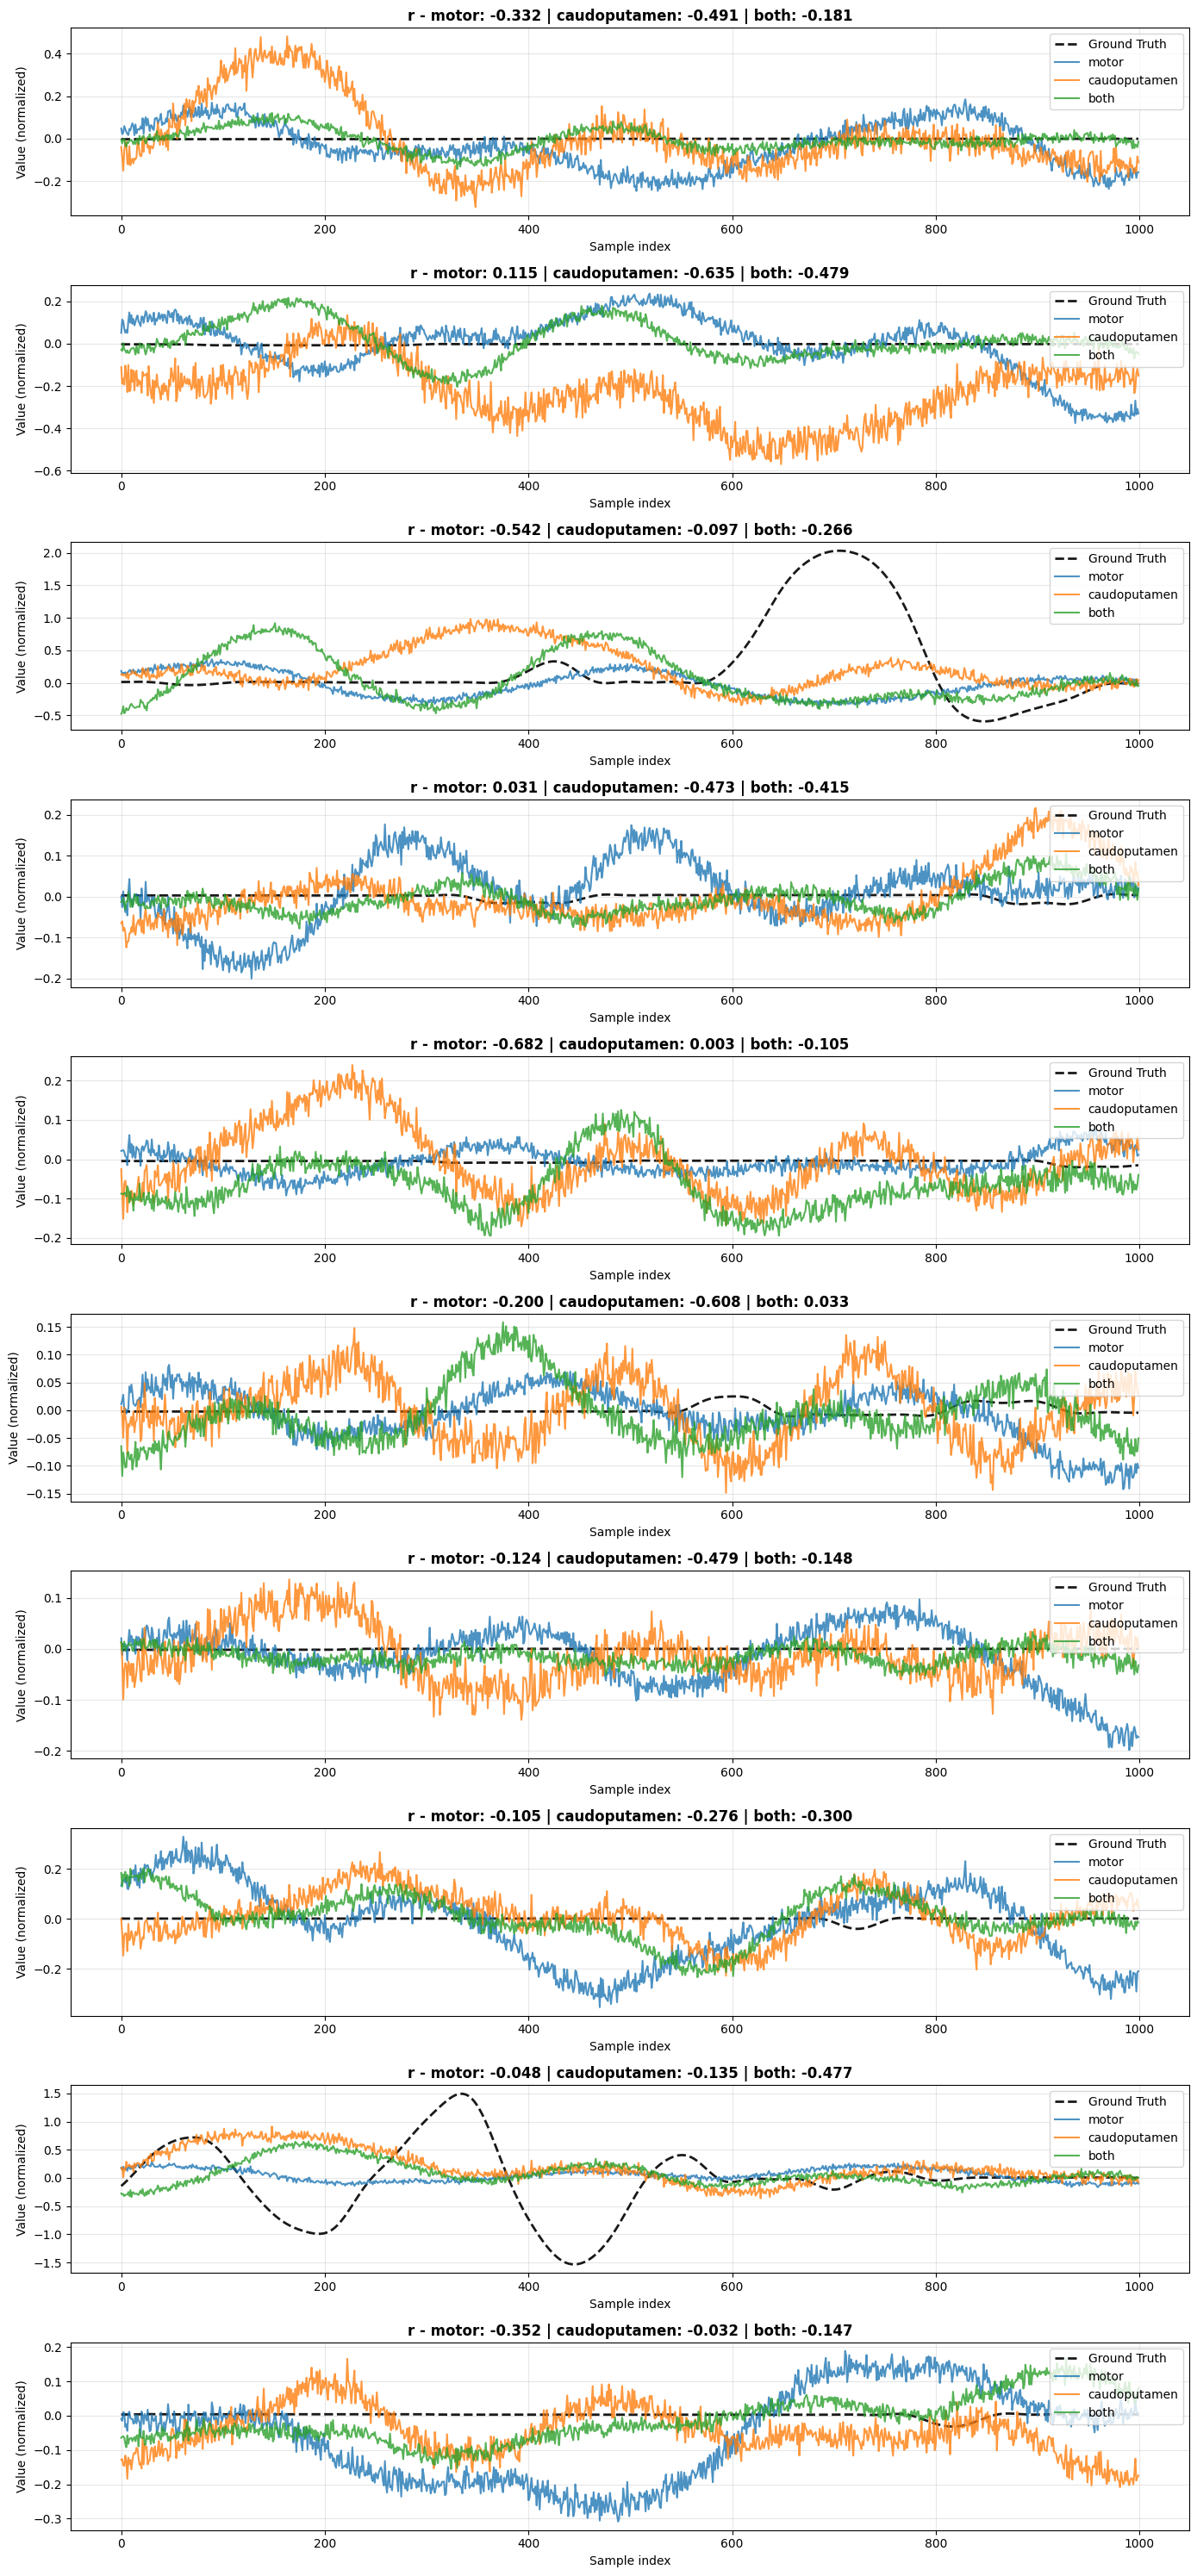

In [15]:
# Compare worst intervals across all three models side-by-side
plot_test_intervals(
    test_results=test_results,
    n_intervals=10,
    order="bottom",
)